# State-conditioned FHR coefficients on CartPole

**Branch `fhr/state-conditioned-c` · 2026-08-23 · seeds 44/66 · SB3 FHRDQN
(tuned recipe: lr 2.3e-3, batch 64, net [256, 256], 50k steps; greedy
10-episode evaluation every 5k steps; return is capped at 500 = solved)**

## Variants at a glance

| # | variant | λ | in one sentence |
|---|---|---|---|
| — | **baseline** | 0 | The tuned SB3 recipe unchanged: the TD loss is the entire objective. |
| 9 | **standard FHR** (global c) | 0.5 | One coefficient vector $c \in \mathbb{R}^2$, shared across all states and episodes, optimised by autodiff jointly with $Q$ in its own optimiser group; the penalty $\lambda\,\mathrm{Huber}\!\big(Q(s_t,a_t) - \sum_j c_j Q(s_{t-j},a_{t-j})\big)$ rides every TD batch. λ = 0.5 is this environment's best recorded value from the earlier sweeps. |
| 1, 3 | **shared c(s, a)** | 0.5 / 1 | $c$ is predicted per transition by a linear head on the Q-network's **penultimate features** (+ one-hot action); penalty gradients also flow into the shared trunk, shaping the representation like an auxiliary head. |
| 2, 4 | **separate c(s, a)** | 0.5 / 1 | $c$ is predicted by an **independent** 64-unit MLP on [observation, one-hot action]; the Q-network feels the penalty only through the Q-values themselves. |
| 5–8 | **ARX** twins | 0.5 / 1 | Same as 1–4 plus learned $d$-coefficients on the two preceding **rewards**, letting the recurrence absorb reward events instead of forcing $Q$ to smooth through them. |

The table is the full design space; **which of these arms the figures below
actually show is read off `experiment.fhr_experiments` in the config** — every
label, colour, panel grid and grouping is derived from that block, so
commenting an entry out drops it from the whole notebook (its runs stay in the
manifest, they are simply not presented) and adding one brings it in. Cell 0
prints the arms in play, plus any config arm with no runs recorded yet.

All predictor heads start with zero weights and the Bellman-init bias, so at
step 0 every state receives exactly the global initialisation
$c = (1{+}1/\gamma, -1/\gamma)$. Recipe hyperparameters are identical across
arms; the only differences are the FHR block entries above
(`configs/config_sb3_ccond.yaml`, order r = 2, coefficient lr 0.03
throughout).

## 0 · Launch - train whatever the config defines

In [ ]:
import pathlib, sys
SRC_RUNNERS = pathlib.Path.cwd().parent / "src"
if str(SRC_RUNNERS) not in sys.path:
    sys.path.insert(0, str(SRC_RUNNERS))
import run_sb3_seeds as runner
import yaml

CONFIG = "configs/config_sb3_ccond.yaml"
MANIFEST = "cached/sb3_runs_manifest_ccond.json"
# Every arm below - launched and analysed - is exactly what the config's
# experiment.fhr_experiments block currently defines; nothing is hardcoded.
EXPERIMENTS = sorted(int(k) for k in
                     (yaml.safe_load(open(CONFIG))["experiment"]
                      .get("fhr_experiments") or {}))
print("config experiments:", EXPERIMENTS)

LAUNCH = False
FORCE_EXP = False
if LAUNCH:
    manifest = runner.launch_all(config=CONFIG, experiments=EXPERIMENTS,
                                 max_workers=14, force=FORCE_EXP)
    print(sorted(manifest["runs"]))
else:
    print("LAUNCH = False - analysing existing runs only")

## Setup - the figure toolkit

Every figure in this notebook comes from
[`analysis.visualisations.fhr_figures`](../../../src/analysis/visualisations/fhr_figures.py),
so the four MuJoCo notebooks plot the same family the same way and a fix lands
once. Three conventions matter for reading the plots:

* **Colour identifies the arm.** Not lambda - an earlier version coloured by
  lambda, which painted every curve of a single-lambda grid (Ant's tuned family
  is entirely lambda = 0.1) the same blue. Arms take successive colours from the
  Okabe-Ito colour-blind-safe palette; the baseline is always near-black;
  **dashed = frozen-c control**, solid = learned c.
* **The seed band is mean +- 1 s.e.m.**, not the min-max envelope. Switch with
  `ff.BAND = "ci95" | "iqr" | "minmax"` *before* `load_family`.
* **Every `fig_*` call returns one standalone figure**, saved by `F.save(...)`
  to `figures/<family>/<name>.pdf` and `.png` at 300 dpi with Type-42 fonts -
  drop the PDF straight into the paper.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

REPO = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "src" / "analysis").is_dir())
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))
from analysis.visualisations import fhr_figures as ff

ff.set_pub_style()
ff.BAND = "sem"          # seed band: "sem" | "ci95" | "iqr" | "minmax"

F = ff.load_family(CONFIG, MANIFEST)
F.summary()

# The sample-efficiency ladder. Read off the TRAINING stream (section 1), not
# the greedy-eval curve - see section 3. Automatic 1-2-5 ladder; pass step=/start= to pin it.
THRESHOLDS = F.auto_thresholds()
print("\nthresholds:", THRESHOLDS)

## 1 · Training curves - the episodes as trained

`rewards.csv`: every training episode's return exactly as the stochastic policy
experienced it (SAC's sampled actions, exploration included), against cumulative
env steps, rolling-mean smoothed. One figure per arm against the shared
baseline, so each panel is a clean two-curve comparison you can paste on its
own. Dots mark where the seed-mean curve first crosses each threshold of the
sample-efficiency ladder; the same crossings are tabulated in section 3.

This is the noisy, un-paired counterpart of section 2's greedy-eval curves -
the gap between the two is the exploration cost, and early-terminated episodes
enter at their actual (short) length.

In [ ]:
# One figure per FHR arm vs the baseline, each saved separately.
for a in F.fhr_arms:
    fig = F.fig_training(a.key, thresholds=THRESHOLDS)
    F.save(fig, f"01_training_{a.key}")
    plt.show()

In [ ]:
# ... and the overlay, for the single-figure version of the same story.
fig = F.fig_overlay("train")
F.save(fig, "01_training_all")
plt.show()

## 2 · Learning curves - greedy evaluation

`eval.csv`: the deterministic policy on fixed reset seeds, so the curves are
paired across arms and the training stream is untouched. Again one figure per
arm against the baseline, then the overlay.

In [ ]:
for a in F.fhr_arms:
    fig = F.fig_eval(a.key)
    F.save(fig, f"02_eval_{a.key}")
    plt.show()

In [ ]:
fig = F.fig_overlay("eval")
F.save(fig, "02_eval_all")
plt.show()

## 3 · Sample efficiency - the claim FHR actually makes

Every prior FHR result in this repo is about **onset / sample efficiency**, not
asymptote. The measurement here is deliberately taken on the **training
stream** (section 1) rather than the greedy-eval curve: the training curve is
what the agent's own experience looks like, it is sampled every episode instead
of every 20k steps, and it is the stream a sample-efficiency claim is about.

For each arm and each threshold we take the first env step at which that seed's
rolling-mean training return reaches it, then average over seeds. A threshold
that only some seeds ever reach is marked - averaging the ones that made it
biases the number downwards, so those points are drawn as open markers and left
off the line rather than allowed to bend it.

In [ ]:
_ = F.table_sample_efficiency(THRESHOLDS)

In [ ]:
fig = F.fig_steps_to_threshold(THRESHOLDS)
F.save(fig, "03_steps_to_threshold")
plt.show()

In [ ]:
# The same numbers as a ratio: > 1 means the arm reached that return in fewer
# environment steps than the baseline.
fig = F.fig_speedup(THRESHOLDS)
F.save(fig, "03_speedup")
plt.show()

## 4 · Final performance - one figure per lambda

Final greedy-eval return, one figure per lambda rung so each is a self-contained
arms-vs-baseline comparison. Bar = seed mean, whisker = +- 1 s.e.m., open dots =
the individual seeds (they are the honest picture of spread on 5 seeds), and the
percentage is the change against the baseline of the same figure.

In [ ]:
for lam in F.lambdas:
    fig = F.fig_final(lam)
    F.save(fig, f"04_final_lambda{lam:g}")
    plt.show()

In [ ]:
# The whole learned-c sweep as one lambda x order map (skipped when the family
# has only one lambda or one order - there is no grid to draw).
if len(F.lambdas) > 1 and len(F.orders) > 1:
    fig = F.fig_grid()
    F.save(fig, "04_grid")
    plt.show()

## 5 · FHR + SAC internals

`train_diagnostics.csv` is one row per gradient step - about 1e6 rows and 180 MB
per run, and the previous version of this notebook re-parsed all of it with
`csv.DictReader` for every one of nine panels. `F.prime_diag_cache()` reads each
file **once** with pandas, reduces it to a per-bin median of every column, gives
it an env-step axis and caches the result to `<run>/diag_binned_600.npz` (about
27 kB). The first call costs a few seconds per run; every call after is
instant, and the panels are a few hundred points per curve instead of a million,
so they render and re-render immediately.

The panel that decides whether the lambda ladder was placed correctly is
**rho = lambda·penalty / TD loss** - the fraction of the critic objective the
recurrence term actually owns. fetch_reach's calibrated pipeline targets
rho in [0.5, 2]; read off which rung of the ladder landed in that band.

In [ ]:
F.prime_diag_cache()      # first call: a few seconds per run. Then cached.
fig = F.fig_internals()
F.save(fig, "05_internals")
plt.show()

In [ ]:
F.table_rho()

## 6 · Hankel low-rankness of the value trajectory

The discrete-action counterpart of the rollout Hankel: roll the trained policy
greedily, Hankel the min-twin `Q(s_t, a_t)` sequence and compare spectra. The
claim under test is that the greedy rollout's Q sequence obeys a low-order
linear recurrence, so FHR arms should concentrate the spectrum faster than the
baseline.

This is a *rollout* measurement. The next section measures rank where the
penalty is actually applied instead.

In [ ]:
fig, table = F.fig_value_hankel(runner)
F.save(fig, "06_value_hankel")
plt.show()
print(f"{'arm':30s} rank@99.9%")
for label, r in table:
    print(f"{label:30s} {r:10d}")

## 7 · Penalised-window Hankel rank - the in-training probe

Rank measured **where the penalty is applied**: on sampled replay windows
(anchor + `window_rank_lags` same-episode predecessors, online critics, buffer
actions) rather than on greedy on-policy rollouts. The probe runs for every arm
**including the lambda = 0 baseline**, which samples and measures the same
windows, so its curve is the control: if FHR operates as a rank constraint, its
arms should push the window rank and the penalty-block tail ratio *below* the
baseline on exactly these windows.

The probe is an **in-training** measurement - it cannot be back-filled from
finished runs. It writes `window_hankel.csv` only when `agent.window_rank_every
> 0` was set in the config the runs were launched from; `F.window_probe_status()`
below says whether this family has it.

In [ ]:
_ = F.window_probe_status()

In [ ]:
if F.has_window_probe:
    for a in F.fhr_arms:
        fig = F.fig_window_rank(a.key)
        F.save(fig, f"07_window_rank_{a.key}")
        plt.show()
    fig = F.fig_window_rank_overlay()
    F.save(fig, "07_window_rank_all")
    plt.show()
    print()
    F.table_window_rank()

## 8 · Compute cost

In [ ]:
import os
rows = []
for k, a in F.arms.items():
    for s, d in F.run_dirs(k):
        ck = d / "checkpoints" / "final.pt"
        if ck.exists():
            rows.append((a.plain, s, (os.path.getmtime(ck)
                                      - os.path.getmtime(d / "config.yaml")) / 60))
for label, s, mins in rows:
    print(f"{label:30s} seed {s}: {mins:6.1f} min")
base_name = F.baseline.plain if F.baseline else None
base = [m for l, _, m in rows if l == base_name]
fhr = [m for l, _, m in rows if l != base_name]
if base and fhr:
    print(f"\nbaseline mean {np.mean(base):.1f} min; FHR-arm mean "
          f"{np.mean(fhr):.1f} min (overhead x{np.mean(fhr)/np.mean(base):.2f})")

## 9 · Findings

1. **Every AR-FHR variant solves CartPole on both seeds (500/500)** — global,
   shared, separate, at λ 0.5 and 1 alike — while the TD-only baseline ends
   seed 66 at 456.7 after a late-run wobble. At a hard score ceiling, FHR's
   contribution is **stabilisation**, and one λ=0.5 global penalty is already
   sufficient; state-conditioning neither helps nor hurts here.
2. **ARX destabilises a constant-reward environment**: with +1 every step
   there are no reward events for the d-lags to explain, so the extra slack
   only weakens the constraint — ARX-separate·λ0.5 reached 500 mid-run and
   collapsed to 18 (seed 66); both λ=1 ARX arms degrade. Third environment
   in a row (after Krull ↑ and MountainCar ↓) where ARX's effect tracks the
   presence of reward kinks exactly.
3. The ARX arms (5–8) are **commented out of the config** as of 2026-08-25, so
   the figures above no longer render them; finding 2 stands on the archived
   runs of that sweep, which remain in
   `cached/sb3_runs_manifest_ccond.json` — uncomment the entries to bring the
   panels back.
4. CartPole cannot rank the AR variants (all ceiling-locked) — it is the
   stability testcase in this trilogy; Acrobot (running) is the
   discriminative one.

## 10 · Bespoke analysis kept from the previous version of this notebook

The cells below are this study's own analyses - they are not part of the shared
figure toolkit and were left exactly as they were. `F.legacy_namespace()`
rebuilds the names they expect (`ARMS`, `INFO`, `BASE`, `GLOBALS_`, `VARIANTS`,
`PER_ARMS`, `labels_of`, `run_dirs`, `curves`, `diag`) from the `Family`, so
they keep running **and** pick up the new per-arm colours, since `ARMS` carries
them.

In [ ]:
import csv, glob, json
try:
    import torch
except ImportError:
    torch = None
globals().update(F.legacy_namespace())
print("legacy names restored:", ", ".join(sorted(F.legacy_namespace())))
if not F.arms:
    print()
    print("*** NO RUNS FOR THIS FAMILY ON THIS MACHINE ***")
    print("The cells below are this study's own code and need its run")
    print("directories under cached/runs/. Everything above degrades to an")
    print("empty-family notice; the cells below will raise instead.")

### Each variant vs the baseline and standard FHR

One panel per variant, three arms per panel: the **variant** (colour), the
**TD-only baseline** (grey) and **standard FHR** (black). Solid = seed 44,
dashed = seed 66.

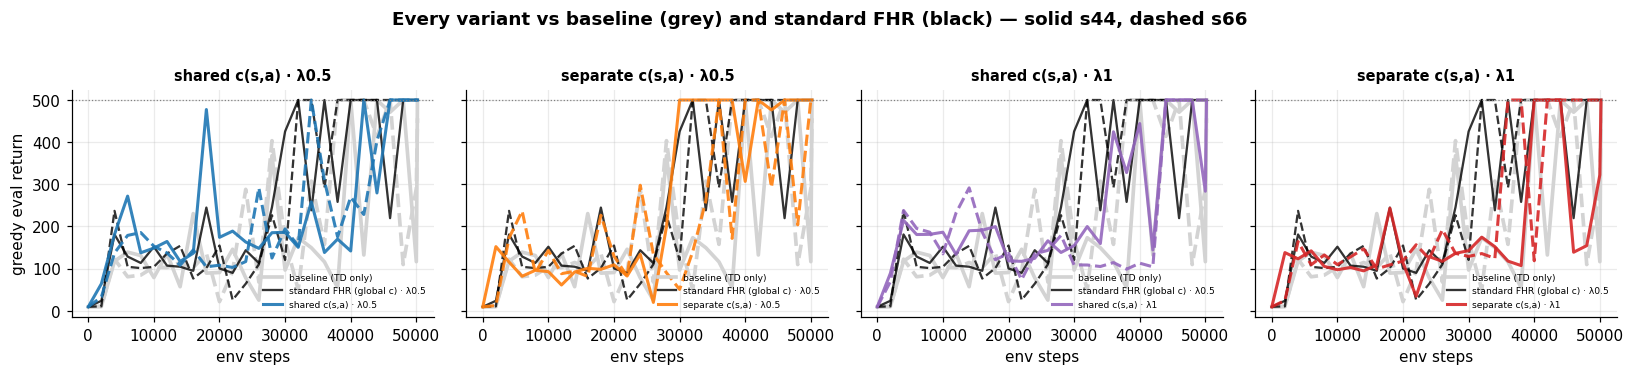

In [5]:
REF_B, REF_G = BASE, (GLOBALS_[0] if GLOBALS_ else None)

def plot_arm(ax, label, colr, lw, alpha=0.9):
    if label is None: return
    for seed, x, y in curves(ARMS[label][0]):
        ax.plot(x, y, STYLE[seed], lw=lw, color=colr, alpha=alpha,
                label=label if seed == SEEDS[0] else None)

def variant_grid(figsize_per=(3.75, 3.3), **kw):
    """One panel per config-defined c(s,a)/ARX variant; unused axes hidden."""
    ncols = min(4, max(1, len(VARIANTS)))
    nrows = max(1, -(-len(VARIANTS) // ncols))
    fig, axes = plt.subplots(nrows, ncols, squeeze=False, sharex=True,
                             sharey=True,
                             figsize=(figsize_per[0] * ncols,
                                      figsize_per[1] * nrows), **kw)
    used = list(zip(axes.ravel(), VARIANTS))
    for ax in axes.ravel()[len(VARIANTS):]:
        ax.set_visible(False)
    return fig, axes, used

fig, axes, used = variant_grid()
for ax, label in used:
    plot_arm(ax, REF_B, "lightgray", 2.4, alpha=1.0)
    plot_arm(ax, REF_G, "black", 1.5, alpha=0.8)
    plot_arm(ax, label, ARMS[label][1], 2.0)
    ax.axhline(500, color="gray", ls=":", lw=0.8)
    ax.set_title(label, fontsize=9.5)
    ax.legend(fontsize=6, loc="lower right")
for ax, _ in used[-axes.shape[1]:]: ax.set_xlabel("env steps")
for ax in axes[:, 0]: ax.set_ylabel("greedy eval return")
fig.suptitle("Every variant vs baseline (grey)"
             + (" and standard FHR (black)" if REF_G else "")
             + f" — solid s{SEEDS[0]}"
             + (f", dashed s{SEEDS[1]}" if len(SEEDS) > 1 else ""),
             fontweight="bold", y=1.02)
plt.tight_layout()


### The recurrence loss — each variant vs standard FHR

Raw (unweighted) penalty over training, rolling-mean smoothed (window = run length / 5), log scale: does the
state-conditioned c fit the sampled Q-transitions better than one global
vector, and does the fit advantage buy anything at the ceiling?

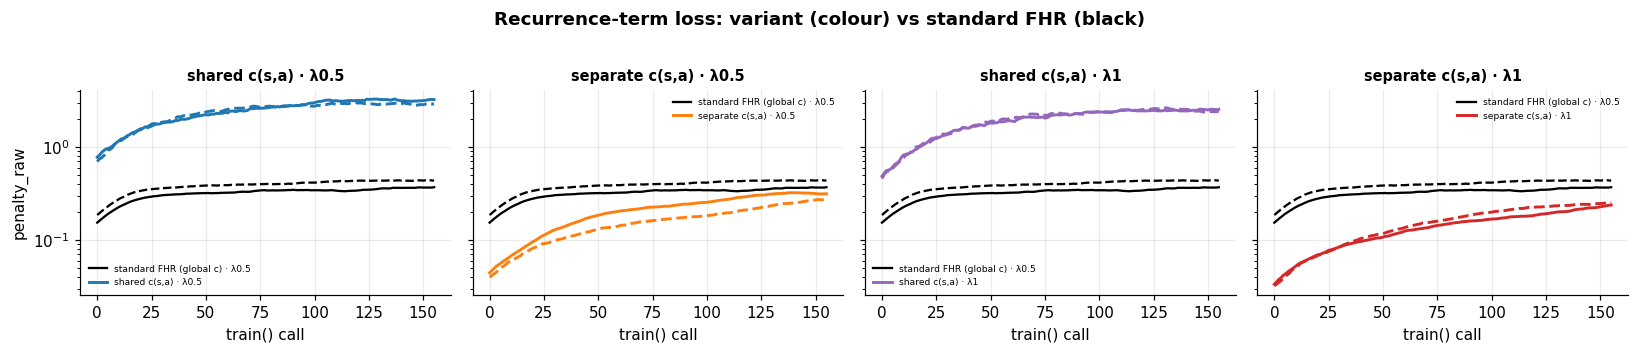

In [6]:
def plot_pen(ax, label, colr, lw):
    if label is None: return
    for seed in SEEDS:
        rel = CMAN["runs"].get(ARMS[label][0], {}).get(seed)
        if not rel: continue
        g = np.genfromtxt(str(pathlib.Path(rel) / "train_diagnostics.csv"),
                          delimiter=",", names=True)
        pen = np.nan_to_num(g["penalty_raw"])
        k = min(200, max(1, len(pen) // 5))   # window fits short runs
        if len(pen) < k: continue
        sm = np.convolve(pen, np.ones(k) / k, "valid")
        ax.plot(sm, STYLE[seed], lw=lw, color=colr,
                label=label if seed == SEEDS[0] else None)

fig, axes, used = variant_grid(figsize_per=(3.75, 3.1))
for ax, label in used:
    plot_pen(ax, REF_G, "black", 1.5)
    plot_pen(ax, label, ARMS[label][1], 1.9)
    ax.set_title(label, fontsize=9.5)
    ax.set_yscale("log")
    ax.legend(fontsize=6)
for ax, _ in used[-axes.shape[1]:]: ax.set_xlabel("train() call")
for ax in axes[:, 0]: ax.set_ylabel("penalty_raw")
fig.suptitle("Recurrence-term loss: variant (colour)"
             + (" vs standard FHR (black)" if REF_G else ""),
             fontweight="bold", y=1.02)
plt.tight_layout()


### Coefficient fields c(s, a) — pole-angle × angular-velocity slice

CartPole's state is 4-D; the informative slice fixes the cart at the centre
(x = ẋ = 0) and sweeps pole angle θ (±12° is the termination bound) against
angular velocity θ̇. Same reading as MountainCar: does the predictor learn
state structure, and where does it bend the recurrence?

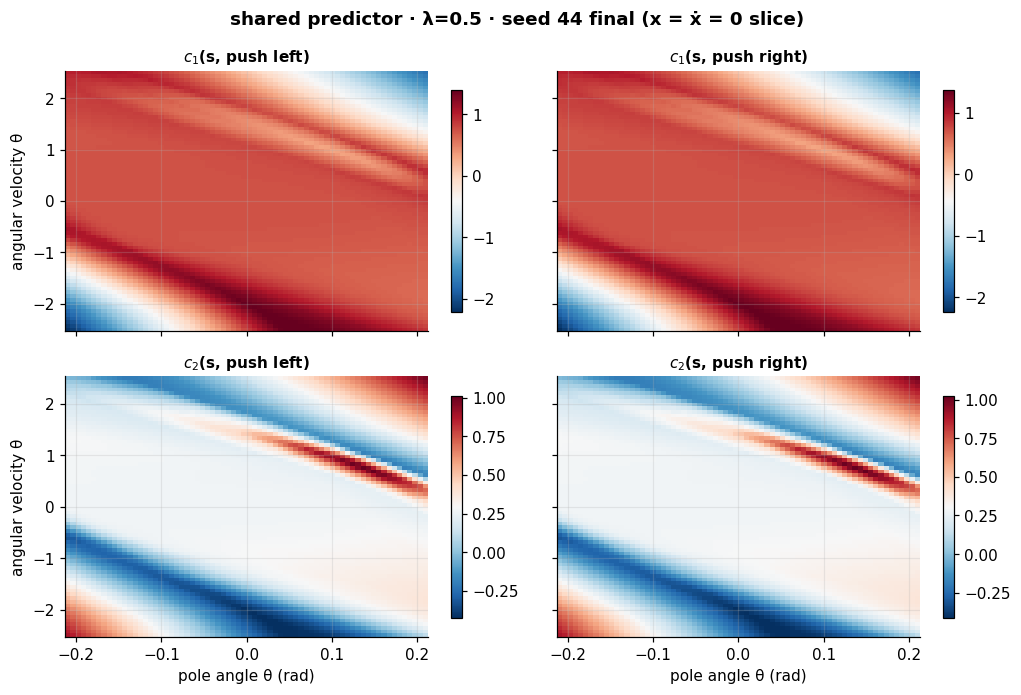

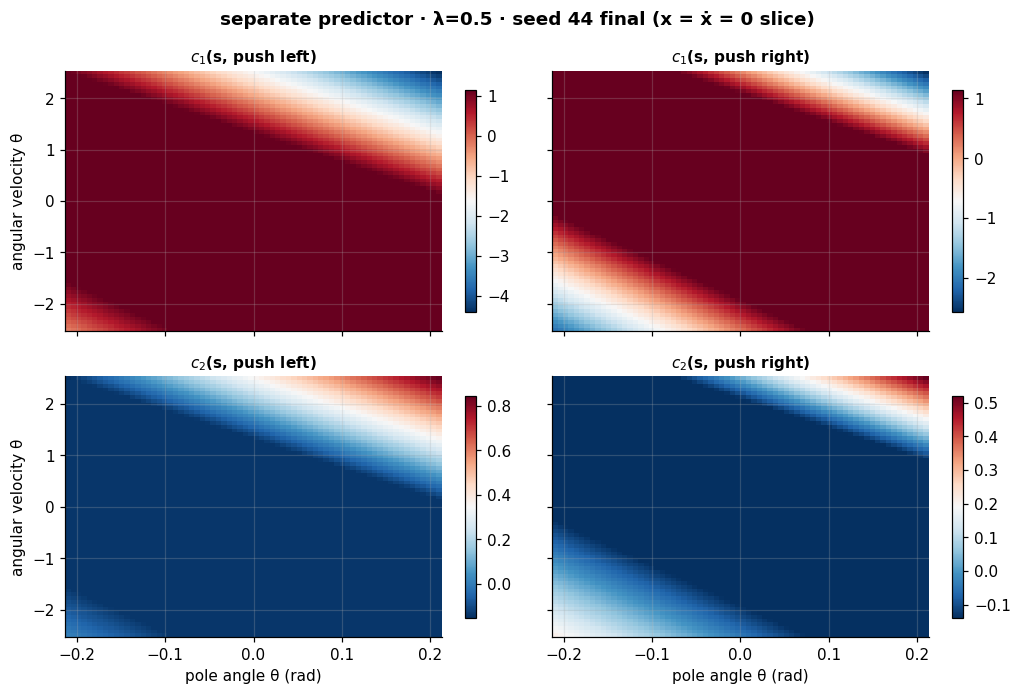

In [7]:
def load_model(arm, seed=None):
    rel = CMAN["runs"][arm][seed or SEEDS[0]]
    return FHRDQN.load(str(pathlib.Path(rel) / "checkpoints" / "final.pt"),
                       device="cpu")

# One field per predictor kind the config defines, at its lowest λ.
PRED_ARMS = []
for pred in [p for p in PRED_ORDER if p]:
    cands = [l for l in ARMS if INFO[l]["pred"] == pred]
    if cands:
        PRED_ARMS.append(min(cands, key=lambda l: INFO[l]["lam"]))

TH, THD = np.meshgrid(np.linspace(-0.21, 0.21, 70), np.linspace(-2.5, 2.5, 70))
GRID = torch.tensor(np.stack([np.zeros(TH.size), np.zeros(TH.size),
                              TH.ravel(), THD.ravel()], 1), dtype=torch.float32)
if not PRED_ARMS:
    print("no state-conditioned arm in the config — no c(s, a) field to show")
for label in PRED_ARMS:
    spec = INFO[label]
    model = load_model(spec["arm"])
    fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4), sharex=True, sharey=True)
    with torch.no_grad():
        for a_i, a_name in enumerate(("push left", "push right")):
            acts = torch.full((len(GRID),), a_i)
            feats = (penultimate_features(model.q_net, GRID)
                     if spec["pred"] == "shared" else GRID)
            c, _ = model.fhr_predictor(feats, acts)
            for lag in range(c.shape[1]):
                ax = axes[lag, a_i]
                im = ax.pcolormesh(TH, THD, c[:, lag].numpy().reshape(TH.shape),
                                   cmap="RdBu_r", shading="auto")
                fig.colorbar(im, ax=ax, shrink=0.85)
                ax.set_title(f"$c_{lag+1}$(s, {a_name})", fontsize=10)
    for ax in axes[1]: ax.set_xlabel("pole angle θ (rad)")
    for ax in axes[:, 0]: ax.set_ylabel("angular velocity θ̇")
    fig.suptitle(f"{spec['pred']} predictor · λ={spec['lam']:g} · seed "
                 f"{SEEDS[0]} final (x = ẋ = 0 slice)", fontweight="bold")
    plt.tight_layout()


### Value functions with and without the regulariser (same slice)

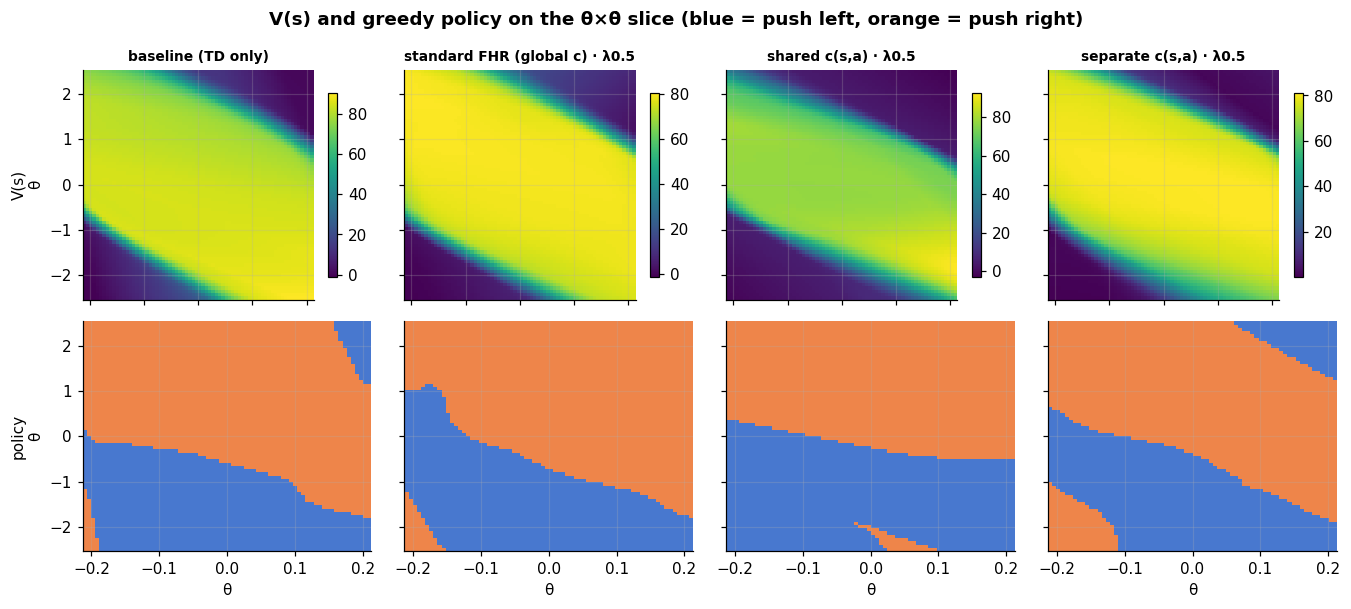

In [8]:
SHOW = [l for l in ([BASE] + GLOBALS_[:1] + PRED_ARMS) if l]
fig, axes = plt.subplots(2, len(SHOW), figsize=(3.1 * len(SHOW), 5.6),
                         sharex=True, sharey=True, squeeze=False)
from matplotlib.colors import ListedColormap
pol_cmap = ListedColormap(["#4878CF", "#EE854A"])
for i, label in enumerate(SHOW):
    model = load_model(ARMS[label][0])
    with torch.no_grad():
        q = model.q_net(GRID).numpy()
    im = axes[0, i].pcolormesh(TH, THD, q.max(1).reshape(TH.shape),
                               cmap="viridis", shading="auto")
    fig.colorbar(im, ax=axes[0, i], shrink=0.8)
    axes[0, i].set_title(label, fontsize=9)
    axes[1, i].pcolormesh(TH, THD, q.argmax(1).reshape(TH.shape),
                          cmap=pol_cmap, vmin=0, vmax=1, shading="auto")
    axes[1, i].set_xlabel("θ")
axes[0, 0].set_ylabel("V(s)\nθ̇"); axes[1, 0].set_ylabel("policy\nθ̇")
fig.suptitle("V(s) and greedy policy on the θ×θ̇ slice "
             "(blue = push left, orange = push right)", fontweight="bold")
plt.tight_layout()


### Hankel low-rankness of the value trajectory

One greedy episode per arm (both reach the 500-step cap): the Q-sequence with
its order-2 recurrence fit, the Hankel matrix as an image, and the singular
value cliff.

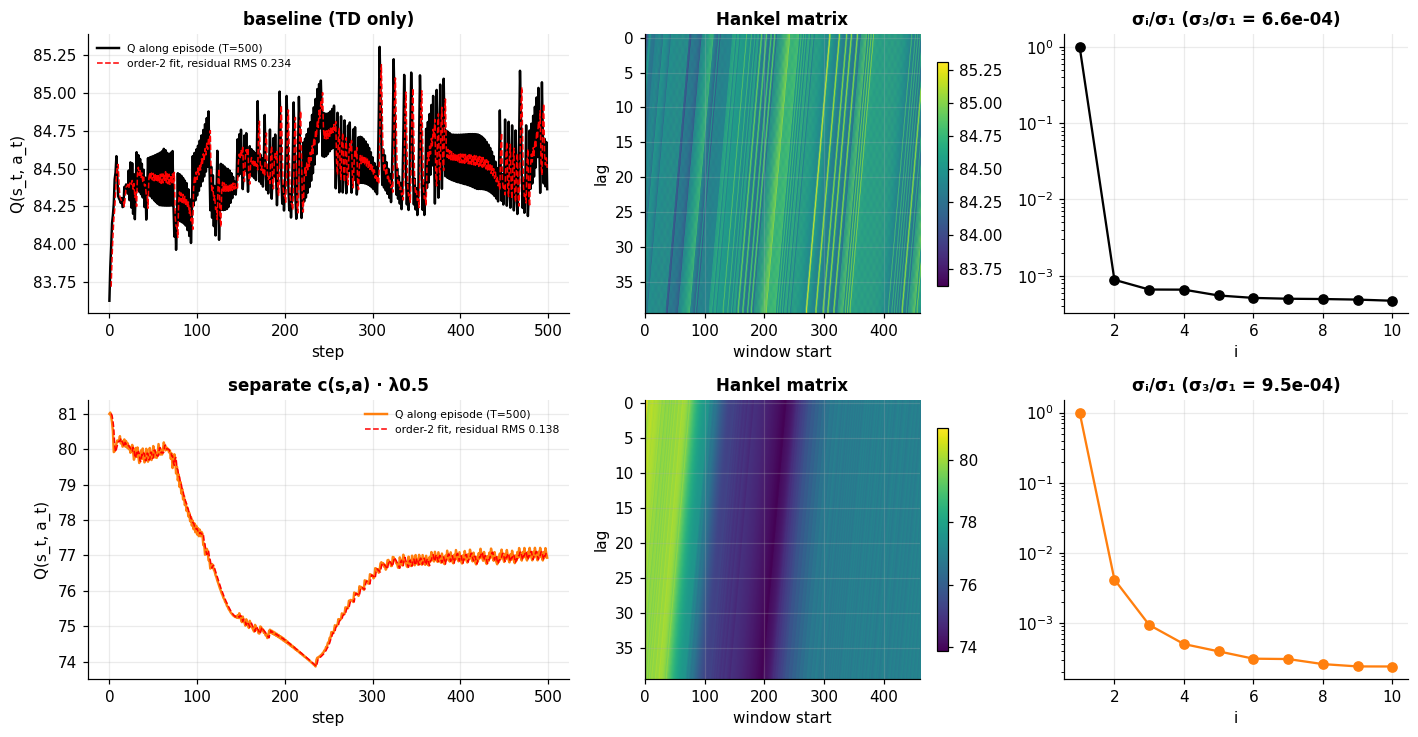

In [9]:
import gymnasium as gym

def greedy_traj_q(model, seed=7, max_steps=500):
    env = gym.make("CartPole-v1")
    obs, _ = env.reset(seed=seed)
    qs, done, trunc = [], False, False
    while not (done or trunc) and len(qs) < max_steps:
        with torch.no_grad():
            q = model.q_net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
        a = int(q.argmax())
        qs.append(float(q[0, a]))
        obs, _, done, trunc, _ = env.step(a)
    env.close()
    return np.array(qs)

# baseline vs one representative regularised arm: the last state-conditioned
# field shown above, else whatever FHR arm the config defines.
REP = (PRED_ARMS[-1] if PRED_ARMS else
       (VARIANTS + GLOBALS_)[0] if (VARIANTS or GLOBALS_) else None)
COMP = [(l, ARMS[l][0], ARMS[l][1]) for l in ([BASE, REP]) if l]
fig, axes = plt.subplots(len(COMP), 3, figsize=(13, 3.4 * len(COMP)),
                         width_ratios=[1.4, 1, 1], squeeze=False)
for row, (label, arm, col) in enumerate(COMP):
    q = greedy_traj_q(load_model(arm))
    T = len(q)
    X = np.stack([q[1:T-1], q[:T-2]], 1); y = q[2:]
    c = np.linalg.solve(X.T @ X + 1e-8 * np.eye(2), X.T @ y)
    pred = X @ c
    ax = axes[row, 0]
    ax.plot(q, lw=1.6, color=col, label=f"Q along episode (T={T})")
    ax.plot(range(2, T), pred, "--", lw=1, color="red",
            label=f"order-2 fit, residual RMS {np.sqrt(((q[2:]-pred)**2).mean()):.3f}")
    ax.set(title=label, xlabel="step", ylabel="Q(s_t, a_t)")
    ax.legend(fontsize=7)
    L = 40
    H = np.array([q[i:i + T - L + 1] for i in range(L)])
    im = axes[row, 1].imshow(H, aspect="auto", cmap="viridis")
    fig.colorbar(im, ax=axes[row, 1], shrink=0.8)
    axes[row, 1].set(title="Hankel matrix", xlabel="window start", ylabel="lag")
    s = np.linalg.svd(H, compute_uv=False)
    axes[row, 2].semilogy(range(1, 11), s[:10] / s[0], "o-", color=col)
    axes[row, 2].set(title=f"σᵢ/σ₁ (σ₃/σ₁ = {s[2]/s[0]:.1e})", xlabel="i")
plt.tight_layout()
